## Data Preparation

#### Load Packages

In [40]:
import pandas as pd
import os
import time
import matplotlib.pyplot as plt

os.chdir(r"C:\Users\ameli\Documents\GitHub\CS4630_Group3_Project2")

#### Configuration

In [41]:
raw_file = "data/raw/HIGGS.csv.gz"
output_directory = "data/processed"

sample_size = 200000
random_seed = 42

#### Load Dataset

In [54]:
print("Loading Dataset...")

start_time = time.time()

df = pd.read_csv(raw_file, header = None)

print(f"Runtime to read data in: {time.time()-start_time} seconds.")

Loading Dataset...
Runtime to read data in: 271.06923937797546 seconds.


In [43]:
print("Original dataset shape:", df.shape)

Original dataset shape: (11000000, 29)


#### Clean Data

- Assign Column Names

- Check for missing values and remove rows with missing values

- Check for duplicate rows and remove

- Check for outliers

##### Define Column Names

In [56]:
df.columns = ['label',
                     'lepton_pT', 'lepton_eta', 'lepton_phi',
                     'missing_E_mag', 'missing_E_phi',
                     'jet1_pT', 'jet1_eta', 'jet1_phi', 'jet1_btag',
                     'jet2_pT', 'jet2_eta', 'jet2_phi', 'jet2_btag',
                     'jet3_pT', 'jet3_eta', 'jet3_phi', 'jet3_btag',
                     'jet4_pT', 'jet4_eta', 'jet4_phi', 'jet4_btag',
                     'm_jj', 'm_jjj', 'm_lv', 'm_jlv',
                     'm_bb', 'm_wbb', 'm_wwbb']

print(f"Number of columns: {len(df.columns)}")


Number of columns: 29


#### Class Balance before Cleaning

In [57]:
df["label"].value_counts(normalize=True)

label
1.0    0.52992
0.0    0.47008
Name: proportion, dtype: float64

##### Drop Rows with NA values and Duplicate Rows

In [45]:
rows_before_na = len(df)
df = df.dropna()
rows_missing_data = rows_before_na - len(df)

print(f"Dropped {rows_missing_data} rows with missing values.")

rows_before_duplicates = len(df)
df = df.drop_duplicates()
rows_duplicate_data = rows_before_duplicates - len(df)

print(f"Dropped {rows_duplicate_data} duplicated rows.")

print(f"Remaining Number of Rows: {len(df)}")

Dropped 0 rows with missing values.
Dropped 278698 duplicated rows.
Remaining Number of Rows: 10721302


Duplicates were removed because the dataset is very large, and there is enough data with them being removed. Removing these values do not harm the statistical power. Duplicates can also distort clustering because they can artificially increase density around certain points and can pull centroids towards the repeated values. 

##### Check for outliers

In [46]:
q1 = df.drop("label", axis = 1).quantile(0.25)
q3 = df.drop("label", axis = 1).quantile(0.75)
iqr = q3 - q1

outliers = ((df.drop("label", axis = 1) < (q1 - 1.5 * iqr)) | (df.drop("label", axis = 1) > (q3 + 1.5 * iqr)))

outlier_count = outliers.sum()
rows_with_outliers = outliers.any(axis = 1).sum()

print(outlier_count)
print(f"There are {rows_with_outliers} rows with at least 1 outlier.")

lepton_pT         418804
lepton_eta             0
lepton_phi             0
missing_E_mag     315809
missing_E_phi          0
jet1_pT           533021
jet1_eta           67930
jet1_phi               0
jet1_btag              0
jet2_pT           430310
jet2_eta           49672
jet2_phi               0
jet2_btag              0
jet3_pT           344166
jet3_eta               0
jet3_phi               0
jet3_btag              0
jet4_pT           360685
jet4_eta               0
jet4_phi               0
jet4_btag              0
m_jj             1497733
m_jjj             797978
m_lv             2129660
m_jlv             541745
m_bb              657516
m_wbb             677174
m_wwbb            647586
dtype: int64
There are 5050127 rows with at least 1 outlier.


There are many outliers detected in the dataset, but they are were not removed. The HIGGS dataset was originally created to identify rare partical events, meaning extreme values may correspond to meaningful physical phenomena rather than errors in the data. Removing these observations could eliminate important information needed to distinguish signal events from background events.

#### Make Sample Dataset for Scalability

K-means runtime is approximately 
$$
O(I \cdot K \cdot n \cdot m) 
$$

where 

- $I$ = number of iterations

- $K$ = number of clusters

- $n$ = number of observations

- $m$ = number of features

https://www.cs.princeton.edu/courses/archive/spr08/cos435/Class_notes/clustering2_toPost.pdf

In [47]:
complexity_estimate = 2 * len(df) * (len(df.columns) - 1)

print(f"The time complexity for K-means on the full dataset is approximately {complexity_estimate}. This means the number of distance operations needed is at least {complexity_estimate}, when the number of iterations is 1.")

The time complexity for K-means on the full dataset is approximately 600392912. This means the number of distance operations needed is at least 600392912, when the number of iterations is 1.


Showing the complexity of K-means, the decision is made to conduct a random sample on the cleaned dataset to have a total of 200,000 observations. 200,000 observations was picked per the project guidelines as methods do not scale. A sample of 200k observations is still large enough to preserve the overall structure of the data while making clustering, PCA, and metric evaluation computationally reasonable. 

In [48]:
df_sample = df.sample(n=sample_size, random_state = random_seed)

print("Sampled dataset shape:", df_sample.shape)
df_sample.head()

Sampled dataset shape: (200000, 29)


,label,lepton_pT,lepton_eta,lepton_phi,missing_E_mag,missing_E_phi,jet1_pT,jet1_eta,jet1_phi,jet1_btag,...,jet4_eta,jet4_phi,jet4_btag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
5236452,0.0,0.548478,-0.058492,0.979747,0.886419,0.773973,1.551918,0.937722,0.576157,2.173076,...,2.452204,-1.606737,0.000000,1.319653,0.891900,0.980309,0.739218,3.544772,2.096405,1.791715
8120250,1.0,0.577577,-0.320490,0.009849,0.824704,-1.251037,0.706566,-1.638856,-0.636922,0.000000,...,-1.203890,1.031420,3.101961,0.868531,1.138811,0.992165,0.831389,0.891734,0.958478,0.819518
10373154,1.0,5.065509,-1.502888,-0.564538,1.623411,-0.701304,1.297067,-2.412226,0.922641,0.000000,...,-1.362127,-1.156149,0.000000,0.754152,1.115983,1.011100,0.816364,0.339321,0.773463,1.278743
7443664,1.0,0.851907,-0.946752,0.742821,1.373478,1.176896,0.705192,0.044535,-0.453421,2.173076,...,-1.152255,-1.049051,0.000000,0.295120,0.711861,0.987153,0.815544,0.921860,1.006651,0.846980
5413574,0.0,0.520844,0.889179,-1.101643,0.585859,-0.184083,1.157915,0.453500,0.072784,0.000000,...,1.025577,-1.585096,3.101961,1.677824,1.429353,0.983400,0.903238,0.378181,1.160369,1.324489


#### Split features and targets

In [49]:
X = df_sample.drop(columns="label")
y = df_sample["label"]

#### Check Balance of Target

In [50]:
sample_balance = y.value_counts(normalize=True)
full_balance = df["label"].value_counts(normalize=True)

balance_df = pd.DataFrame({
    "Full Dataset": full_balance,
    "Sample Dataset": sample_balance
})

print(balance_df)

       Full Dataset  Sample Dataset
label                              
1.0        0.543695        0.543315
0.0        0.456305        0.456685


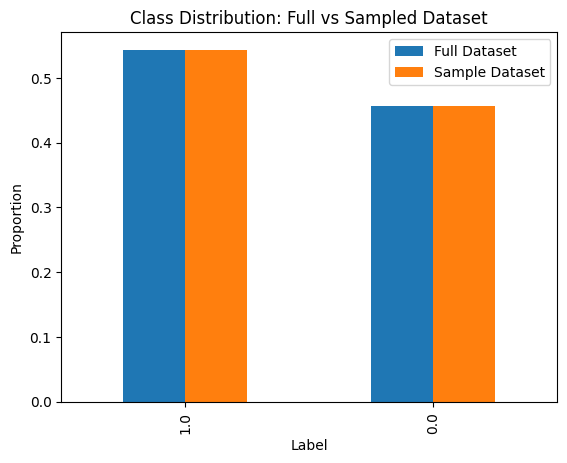

In [51]:
balance_df.plot(kind="bar")
plt.title("Class Distribution: Full vs Sampled Dataset")
plt.xlabel("Label")
plt.ylabel("Proportion")
plt.legend()
plt.show()

#### Create Results Table

In [52]:
os.makedirs("results/metrics", exist_ok=True)

columns = ["method", "dataset_version", "n_clusters", "n_rows", "n_features", "training_time_seconds", "prediction_time_seconds", "iterations", "accuracy", "silhouette_score", "davies_bouldin", "compactness", "separation"]

df_summary = pd.DataFrame(columns=columns)

print("Created clustering_summary.csv to keep results in one place.")

Created clustering_summary.csv to keep results in one place.


#### Save Processed Files

In [53]:
df_sample.to_csv(f"{output_directory}/higgs_sample.csv", index = False)
print("Saved higgs_sample.csv")

X.to_csv(f"{output_directory}/X_sample.csv", index = False)
print("Saved X_sample.csv")

y.to_csv(f"{output_directory}/y_sample.csv", index = False)
print("Saved y_sample.csv")

df_summary.to_csv("results/metrics/clustering_summary.csv", index=False)
print("Saved clustering_summary.csv")


Saved higgs_sample.csv
Saved X_sample.csv
Saved y_sample.csv
Saved clustering_summary.csv
